In [22]:
import json, re, time, pathlib
import requests
import pandas as pd

BASE = "https://classes.cornell.edu/api/2.0"
TERMS = ["FA21", "SP22", "FA22", "SP23", "FA23", "SP24", "FA24", "SP25", "FA25", "SP26"]
#TERMS = ["FA21"]
RAW = pathlib.Path("raw")
RAW.mkdir(exist_ok=True)

successfull response

In [23]:
def get_subjects(term):
    r = requests.get(f"{BASE}/config/subjects.json", params={"roster": term})
    r.raise_for_status()
    return r.json()["data"]["subjects"]

def fetch(term, subject):
    path = RAW / f"{term}_{subject}.json"
    if path.exists():
        return
    r = requests.get(f"{BASE}/search/classes.json",
                     params={"roster": term, "subject": subject})
    r.raise_for_status()
    path.write_text(json.dumps(r.json()))
    time.sleep(0.5)

failed = []
for term in TERMS:
    for s in get_subjects(term):
        code = s["value"]  # if this errors, print(s) and use the field that holds the subject code
        try:
            fetch(term, code)
        except Exception as e:
            failed.append((term, code, str(e)))
print("failed requests:", len(failed))

failed requests: 1


In [16]:
rows = []
for path in sorted(RAW.glob("*.json")):
    term = path.stem.split("_", 1)[0]
    classes = json.loads(path.read_text()).get("data", {}).get("classes", [])
    for c in classes:
        rows.append({
            "term": term,
            "crseId": c.get("crseId"),
            "subject": c.get("subject"),
            "catalogNbr": c.get("catalogNbr"),
            "title": c.get("titleLong") or "",
            "description": c.get("description") or "",
            "college": c.get("acadGroup"),
            "career": c.get("acadCareer"),
        })
df = pd.DataFrame(rows)
df["term"] = pd.Categorical(df["term"], categories=TERMS, ordered=True)
print(df.shape)

(4298, 8)


In [17]:
text = df["title"] + " " + df["description"]

narrow = re.compile(r"artificial intelligence|machine learning", re.I)
broad = re.compile(r"artificial intelligence|machine learning|deep learning|neural network|"
                   r"large language model|natural language processing|reinforcement learning|"
                   r"computer vision", re.I)
ai_word = re.compile(r"\bAI\b")

df["ai_narrow"] = text.apply(lambda t: bool(narrow.search(t) or ai_word.search(t)))
df["ai_broad"] = text.apply(lambda t: bool(broad.search(t) or ai_word.search(t)))

In [18]:
by_id = df.drop_duplicates(["term", "crseId"])
by_text = df.drop_duplicates(["term", "title", "description"])

rules = {"no dedupe": df, "crseId (main)": by_id, "title+description": by_text}
print(pd.DataFrame({
    name: {"courses": len(d),
           "AI share (narrow)": round(d["ai_narrow"].mean(), 3),
           "AI share (broad)": round(d["ai_broad"].mean(), 3)}
    for name, d in rules.items()
}).T)

                   courses  AI share (narrow)  AI share (broad)
no dedupe           4298.0              0.011             0.016
crseId (main)       3520.0              0.012             0.016
title+description   3218.0              0.011             0.015


      courses  ai_narrow  ai_broad
term                              
FA21     3520      0.012     0.016


<Axes: title={'center': 'Share of Cornell courses mentioning AI, by term'}, xlabel='term', ylabel='share of courses mentioning AI'>

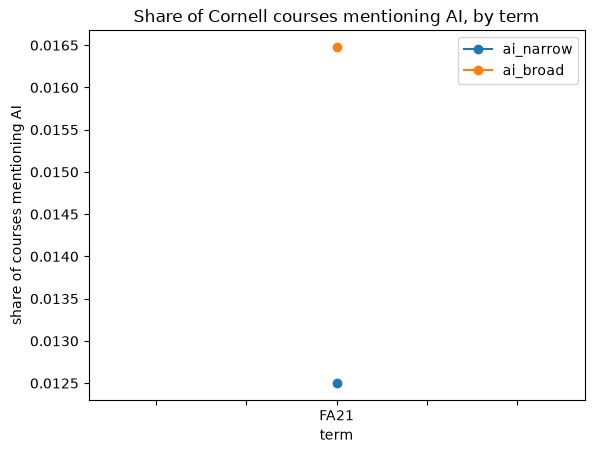

In [19]:
by_term = by_id.groupby("term", observed=True).agg(
    courses=("crseId", "size"),
    ai_narrow=("ai_narrow", "mean"),
    ai_broad=("ai_broad", "mean"),
)
print(by_term.round(3))
by_term[["ai_narrow", "ai_broad"]].plot(
    marker="o", ylabel="share of courses mentioning AI",
    title="Share of Cornell courses mentioning AI, by term")

In [20]:
by_subject = (by_id.groupby("subject")
              .agg(courses=("crseId", "size"),
                   ai_courses=("ai_broad", "sum"),
                   share=("ai_broad", "mean"))
              .query("courses >= 20")
              .sort_values("share", ascending=False))
print(by_subject.head(15).round(3))

         courses  ai_courses  share
subject                            
CS            94          26  0.277
PSYCH         29           4  0.138
BTRY          21           2  0.095
INFO          42           4  0.095
STSCI         24           2  0.083
NBA           63           5  0.079
ECE           50           3  0.060
PLSCI         23           1  0.043
MAE           60           2  0.033
ASIAN         32           1  0.031
ORIE          50           1  0.020
MATH          59           1  0.017
LAW           70           0  0.000
LING          25           0  0.000
LA            27           0  0.000


In [21]:
blank = by_id["description"].str.strip() == ""
print(blank.groupby(by_id["term"], observed=True).mean().round(3))

term
FA21    0.036
Name: description, dtype: float64
